<a href="https://colab.research.google.com/github/Bigoal/flyrank-ml-internship/blob/main/work/notebooks/capstone.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<a href="https://colab.research.google.com/github/Bigoal/flyrank-ml-internship/blob/main/work/notebooks/capstone.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## 1. Question

**Research question.** Which pages should a FlyRank content editor look at first because their organic search impressions are likely to fall next month?

**Unit, output, action.** One row is one page (content item) in one month. The output is a score that ranks pages. An editor reviews the top of the ranked list: a title/snippet review, a content review, or just monitoring.

**Cost of a wrong call.** A false alarm costs review time. A miss leaves a falling page unreviewed for a month.

**Claim language.** Everything here is *observed*, *measured*, *directional*, or *decision-support*. No causal claims, and nothing about how Google works.

In [3]:
import os, sys, json, time, warnings, subprocess, importlib
warnings.filterwarnings("ignore")
import numpy as np, pandas as pd
from IPython.display import display

def _ensure(pkg):
    try:
        importlib.import_module(pkg)
    except ImportError:
        subprocess.run([sys.executable, "-m", "pip", "install", "-q", pkg], check=True)
for _p in ["duckdb", "lightgbm", "scipy"]:
    _ensure(_p)

import duckdb, lightgbm as lgb
from scipy.stats import rankdata
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.model_selection import cross_val_score
try:
    from xgboost import XGBClassifier
except Exception:
    XGBClassifier = None

# ---- one place for every choice the paper reports ----
SEED = 42
np.random.seed(SEED)
REL = os.environ.get("FLYRANK_REL", "hf://datasets/FlyRank/internship-warehouse")
DECLINE_CUT = -0.20     # "declining" = impressions fell 20% or more, month over month
K_SHRINK = 50           # CTR smoothing strength, in pseudo-impressions
PERIODS = {             # name: (decision month, outcome month)
    "TRAIN": ("2026-02", "2026-03"),
    "DEV":   ("2026-04", "2026-05"),
    "FINAL": ("2026-05", "2026-06"),
}
SCORE_MONTH = "2026-06"  # newest complete month: used for the recommendation queue
BASE_FEATURES = ["gsc_avg_position_weighted", "gsc_clicks_month", "sessions_organic_month", "search_volume", "cpc"]
FEATURES = BASE_FEATURES + ["shrunk_ctr"]
N_BOOT = 200
OUTDIR = "capstone_artifacts"
os.makedirs(OUTDIR, exist_ok=True)
print({"REL": REL if not REL.startswith("hf://") else "hf://…/internship-warehouse", "decline_cut": DECLINE_CUT, "k_shrink": K_SHRINK, "periods": PERIODS})

{'REL': 'hf://…/internship-warehouse', 'decline_cut': -0.2, 'k_shrink': 50, 'periods': {'TRAIN': ('2026-02', '2026-03'), 'DEV': ('2026-04', '2026-05'), 'FINAL': ('2026-05', '2026-06')}}


## 2. Data

**Release and tables.** The FlyRank ML Internship warehouse (full release on Hugging Face, gated). Two tables: `fact_content_daily_performance` (monthly partitions, Feb to Jun 2026) and `dim_content` (`search_volume`, `cpc`).

**Windows.** Features come from a *decision month*; the label comes from the *next* month.

| Period | Features from | Label from | Role |
|---|---|---|---|
| TRAIN | Feb 2026 | Mar 2026 | fit models |
| DEV | Apr 2026 | May 2026 | design and compare |
| FINAL | May 2026 | Jun 2026 | report |
| SCORE | Jun 2026 | (unknown yet) | recommendation queue |

**Excluded, and why.**
- Deleted content (`is_deleted`), and pages with no impressions in the decision month (nothing to decline).
- Pages with no outcome-month row (the outcome is unobserved). The share is printed below.
- Anything that defines the label (outcome impressions, trend fields) is never a feature. Pseudonymous IDs are used for grouping and joins only.

**Public-safe.** No client names, domains, URLs, or queries. Client hashes are replaced by "Client 1…n" labels, and only aggregate numbers leave this notebook.

In [4]:
con = duckdb.connect()
if REL.startswith("hf://"):
    def _hf_token():
        try:
            from google.colab import userdata
            return userdata.get("HF_TOKEN")
        except Exception:
            return os.environ["HF_TOKEN"]
    con.execute("INSTALL httpfs"); con.execute("LOAD httpfs")
    con.execute(f"CREATE SECRET (TYPE huggingface, TOKEN '{_hf_token()}')")

_month_cache = {}
def month_agg(month):
    """One row per page for one month (cached, so each partition is read once)."""
    if month not in _month_cache:
        _month_cache[month] = con.sql(f"""
            SELECT f.content_hash_id,
                   MIN(f.client_hash_id) AS client_hash_id,
                   SUM(f.gsc_impressions) AS impressions,
                   SUM(f.gsc_clicks) AS clicks,
                   SUM(f.sessions_organic) AS sessions,
                   SUM(CASE WHEN f.gsc_data_available IS TRUE THEN f.gsc_avg_position * f.gsc_impressions ELSE 0 END)
                     / NULLIF(SUM(CASE WHEN f.gsc_data_available IS TRUE THEN f.gsc_impressions ELSE 0 END), 0)
                     AS avg_position_weighted
            FROM read_parquet('{REL}/fact_content_daily_performance/month={month}/data_0.parquet') f
            JOIN read_parquet('{REL}/dim_content.parquet') dc ON f.content_hash_id = dc.content_hash_id
            WHERE dc.is_deleted IS NOT TRUE
            GROUP BY f.content_hash_id
        """).df()
    return _month_cache[month]

dim_content = con.sql(f"SELECT content_hash_id, search_volume, cpc FROM read_parquet('{REL}/dim_content.parquet')").df()

def decision_frame(month):
    d = month_agg(month).rename(columns={"impressions": "impressions_decision", "clicks": "gsc_clicks_month",
                                         "sessions": "sessions_organic_month",
                                         "avg_position_weighted": "gsc_avg_position_weighted"})
    d = d.merge(dim_content, on="content_hash_id", how="left")
    return d[d["impressions_decision"] > 0].reset_index(drop=True)

coverage = {}
def forward_frame(name, decision_month, outcome_month):
    d = decision_frame(decision_month)
    o = month_agg(outcome_month)[["content_hash_id", "impressions"]].rename(columns={"impressions": "impressions_outcome"})
    m = d.merge(o, on="content_hash_id", how="left")
    coverage[name] = {"visible": len(m), "dropped": int(m["impressions_outcome"].isna().sum())}
    m = m.dropna(subset=["impressions_outcome"]).copy()
    m["is_declining_label"] = (((m["impressions_outcome"] - m["impressions_decision"]) / m["impressions_decision"]) <= DECLINE_CUT).astype(int)
    return m.reset_index(drop=True)

frames = {name: forward_frame(name, *months) for name, months in PERIODS.items()}

# anonymous client labels, ordered by page count (hashes never printed or published)
_counts = pd.concat([f["client_hash_id"] for f in frames.values()]).value_counts()
CLIENT_LABEL = {c: f"Client {i + 1}" for i, c in enumerate(_counts.index)}
for f in frames.values():
    f["client"] = f["client_hash_id"].map(CLIENT_LABEL)
    f.drop(columns=["client_hash_id", "content_hash_id"], inplace=True)

regime = []
for name, f in frames.items():
    regime.append(dict(period=name, decision_month=PERIODS[name][0], outcome_month=PERIODS[name][1],
                       pages=len(f), clients=int(f["client"].nunique()),
                       decline_rate=f["is_declining_label"].mean(),
                       agg_impressions_change=f["impressions_outcome"].sum() / f["impressions_decision"].sum() - 1,
                       zero_outcome_share=(f["impressions_outcome"] == 0).mean(),
                       dropped_no_outcome_share=coverage[name]["dropped"] / coverage[name]["visible"]))
regime_df = pd.DataFrame(regime)
display(regime_df.round(3))
print("Missing values per feature (TRAIN):")
print(frames["TRAIN"][BASE_FEATURES].isna().mean().round(3).to_string())

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

,period,decision_month,outcome_month,pages,clients,decline_rate,agg_impressions_change,zero_outcome_share,dropped_no_outcome_share
0,TRAIN,2026-02,2026-03,145066,41,0.262,0.469,0.076,0.037
1,DEV,2026-04,2026-05,194663,49,0.505,-0.123,0.058,0.000
2,FINAL,2026-05,2026-06,237505,55,0.728,-0.220,0.223,0.000


Missing values per feature (TRAIN):
gsc_avg_position_weighted    0.000
gsc_clicks_month             0.000
sessions_organic_month       0.499
search_volume                0.105
cpc                          0.105


## 3. Methodology

**Label.** A page is *declining* if its impressions in the outcome month are at least 20% below its impressions in the decision month. A page that falls to zero counts as declining. This is a defined threshold, not a measured harm, so the paper reports it as such.

**Features (6).** Average position (impression-weighted), clicks, organic sessions, search volume, CPC, and a smoothed click-through rate (`shrunk_ctr`). Missing values are filled with the *training* medians only.

**Smoothed CTR, in plain words.** Raw CTR is unreliable for pages with few impressions (0 clicks out of 10 looks the same as 0 out of 10,000). Smoothed CTR pulls each page toward the overall CTR in proportion to how little data it has.

**Baseline.** Rank pages by smoothed CTR, lowest first. No fitting, fully transparent.

**Models.** Logistic regression (scaled), random forest, XGBoost, LightGBM. All are fit on TRAIN only. LightGBM was named the primary model in the interactive runs before this notebook was consolidated (best top-50 result on DEV), and that label is not changed after looking at the results.

**Which ranker drives the recommendation queue.** Decided by the *within-client* test in Section 4 (does the score order pages inside a client, in both DEV and FINAL?), not by global AUC, which mixes in differences between clients.

**Validation design.**
- *Time-aware:* fit on earlier months, evaluate on later ones.
- *Client-aware:* pages from one client move together, so uncertainty comes from resampling whole clients, and the score is also checked *within* each client.
- The DEV period (Apr to May) shaped the baseline design. The FINAL period (May to Jun) was inspected once in interactive diagnostics before this notebook was consolidated, and no modeling choice was tuned on it afterward. It is a fixed reporting period, not a blind test.

**Leakage checks.** No label ingredients or IDs among the features; a negative control that adds them back and should score near-perfect; fill values and the CTR reference level come from TRAIN only; each period's features come strictly before its label month.

In [5]:
class Prep:
    """Everything learned from data lives here and is fit on TRAIN only."""
    def fit(self, frame):
        self.pop_ctr = frame["gsc_clicks_month"].sum() / frame["impressions_decision"].sum()
        self.medians = frame[BASE_FEATURES].median()
        return self
    def transform(self, frame):
        X = frame[BASE_FEATURES].fillna(self.medians).copy()
        X["shrunk_ctr"] = (frame["gsc_clicks_month"].fillna(0) + K_SHRINK * self.pop_ctr) / (frame["impressions_decision"] + K_SHRINK)
        return X[FEATURES]

prep = Prep().fit(frames["TRAIN"])
X = {name: prep.transform(f) for name, f in frames.items()}
y = {name: f["is_declining_label"].values for name, f in frames.items()}

# ---- leakage checks ----
FORBIDDEN = {"impressions_outcome", "is_declining_label", "trend_direction", "trend_pct", "impressions_pct_change",
             "content_hash_id", "client_hash_id", "client"}
assert not (set(FEATURES) & FORBIDDEN), "a forbidden column is in the feature list"
assert PERIODS["TRAIN"][1] < PERIODS["DEV"][0], "TRAIN label month must come before DEV feature month"
for _n, (_d, _o) in PERIODS.items():
    assert _d < _o, "features must come before the label month"

def cv_auc(Xa, ya):
    pipe = make_pipeline(StandardScaler(), LogisticRegression(max_iter=1000))
    return cross_val_score(pipe, Xa, ya, cv=5, scoring="roc_auc").mean()

_s = frames["TRAIN"].sample(min(30000, len(frames["TRAIN"])), random_state=SEED)
_Xs = X["TRAIN"].loc[_s.index]
honest = cv_auc(_Xs, _s["is_declining_label"])
leaky = cv_auc(_Xs.assign(impressions_outcome=_s["impressions_outcome"], impressions_decision=_s["impressions_decision"]),
               _s["is_declining_label"])
print(f"Negative control (TRAIN, 5-fold): honest features AUC={honest:.3f} | + label ingredients AUC={leaky:.3f}")
print("The second number should be far above the first. It shows why those columns are never features.")
print(f"Reference CTR (from TRAIN only) = {prep.pop_ctr:.4f}")

# ---- models ----
def make_models(y_train):
    models = {
        "logreg": make_pipeline(StandardScaler(), LogisticRegression(max_iter=1000, class_weight="balanced")),
        "random_forest": RandomForestClassifier(n_estimators=300, max_depth=6, min_samples_leaf=50,
                                                class_weight="balanced", random_state=SEED, n_jobs=-1),
        "lightgbm": lgb.LGBMClassifier(n_estimators=300, max_depth=4, learning_rate=0.05,
                                       class_weight="balanced", random_state=SEED, verbosity=-1),
    }
    if XGBClassifier is not None:
        models["xgboost"] = XGBClassifier(n_estimators=300, max_depth=4, learning_rate=0.05, eval_metric="auc",
                                          scale_pos_weight=(y_train == 0).sum() / max((y_train == 1).sum(), 1),
                                          random_state=SEED)
    return models

models = make_models(y["TRAIN"])
for _name, _m in models.items():
    _m.fit(X["TRAIN"], y["TRAIN"])

MODEL_ORDER = ["baseline"] + [m for m in ["logreg", "random_forest", "xgboost", "lightgbm"] if m in models]
PRIMARY = "lightgbm"
def score(name, period):
    if name == "baseline":
        return -X[period]["shrunk_ctr"].values      # lowest smoothed CTR = highest priority
    return models[name].predict_proba(X[period])[:, 1]
scores = {n: {p: score(n, p) for p in PERIODS} for n in MODEL_ORDER}
print("Models fit on TRAIN:", MODEL_ORDER)

Negative control (TRAIN, 5-fold): honest features AUC=0.615 | + label ingredients AUC=0.960
The second number should be far above the first. It shows why those columns are never features.
Reference CTR (from TRAIN only) = 0.0033
Models fit on TRAIN: ['baseline', 'logreg', 'random_forest', 'xgboost', 'lightgbm']


## 4. Results (vs baseline)

Every model is scored on the same rows with the same metrics. The base rate (share of pages that declined) is printed next to every number, because a high top-of-list hit rate can just reflect a high base rate. **Lift** is the top-of-list hit rate divided by the base rate; 1.0 means no better than picking pages at random.

Three views, in order of how much weight they deserve:
1. **AUC** over the whole ranking, with client-level uncertainty.
2. **Within-client AUC:** does the score order pages *inside* a client? This removes differences between clients, which are large.
3. **Lift at the top 1% and top 10%**, with top-50 precision shown as a secondary number only (50 pages is a small, client-clustered sample).

In [6]:
def fast_auc(yv, s):
    r = rankdata(s)
    n1 = yv.sum(); n0 = len(yv) - n1
    return (r[yv == 1].sum() - n1 * (n1 + 1) / 2) / (n1 * n0)

from sklearn.metrics import roc_auc_score
assert abs(fast_auc(y["TRAIN"], scores["baseline"]["TRAIN"]) - roc_auc_score(y["TRAIN"], scores["baseline"]["TRAIN"])) < 1e-9

def evaluate(yv, s):
    n = len(yv); base = yv.mean()
    order = np.argsort(-s, kind="stable")
    out = {"n": int(n), "base_rate": float(base), "auc": float(fast_auc(yv, s))}
    for label, k in [("top50", 50), ("top1pct", max(int(0.01 * n), 1)), ("top10pct", max(int(0.10 * n), 1))]:
        p = yv[order[:k]].mean()
        out[f"precision_{label}"] = float(p); out[f"lift_{label}"] = float(p / base)
    return out

rows = []
for n in MODEL_ORDER:
    for p in PERIODS:
        rows.append({"model": n, "period": p, **evaluate(y[p], scores[n][p])})
results_df = pd.DataFrame(rows)
show = ["model", "period", "n", "base_rate", "auc", "lift_top1pct", "lift_top10pct", "precision_top50"]
for p in ["DEV", "FINAL"]:
    print(f"--- {p} ({PERIODS[p][0]} -> {PERIODS[p][1]}) ---")
    display(results_df[results_df["period"] == p][show].round(3).reset_index(drop=True))
print("--- TRAIN (in-sample, for the overfitting gap only) ---")
display(results_df[results_df["period"] == "TRAIN"][["model", "auc"]].round(3).reset_index(drop=True))

--- DEV (2026-04 -> 2026-05) ---


,model,period,n,base_rate,auc,lift_top1pct,lift_top10pct,precision_top50
0,baseline,DEV,194663,0.505,0.597,1.582,1.348,0.88
1,logreg,DEV,194663,0.505,0.529,0.724,0.979,0.38
2,random_forest,DEV,194663,0.505,0.500,0.790,0.849,0.68
3,xgboost,DEV,194663,0.505,0.491,1.093,0.888,0.74
4,lightgbm,DEV,194663,0.505,0.492,1.106,0.886,0.78


--- FINAL (2026-05 -> 2026-06) ---


,model,period,n,base_rate,auc,lift_top1pct,lift_top10pct,precision_top50
0,baseline,FINAL,237505,0.728,0.542,1.156,1.036,0.78
1,logreg,FINAL,237505,0.728,0.557,0.765,1.137,0.30
2,random_forest,FINAL,237505,0.728,0.616,1.352,1.218,0.90
3,xgboost,FINAL,237505,0.728,0.599,1.217,1.205,0.84
4,lightgbm,FINAL,237505,0.728,0.600,1.177,1.203,0.84


--- TRAIN (in-sample, for the overfitting gap only) ---


,model,auc
0,baseline,0.479
1,logreg,0.603
2,random_forest,0.689
3,xgboost,0.703
4,lightgbm,0.703


In [7]:
# ---- client-level uncertainty: resample whole clients ----
def client_groups(frame):
    return {c: idx for c, idx in frame.groupby("client").indices.items()}

def boot_global(period, a, b, n_boot=N_BOOT, seed=SEED):
    rng = np.random.default_rng(seed)
    yv = y[period]; g = client_groups(frames[period]); names = list(g)
    sa, sb = scores[a][period], scores[b][period]
    res = []
    for _ in range(n_boot):
        idx = np.concatenate([g[names[i]] for i in rng.integers(0, len(names), len(names))])
        yb = yv[idx]
        if yb.min() == yb.max():
            continue
        res.append((fast_auc(yb, sa[idx]), fast_auc(yb, sb[idx])))
    return np.array(res)

def within_client(period, name, min_pages=200, min_each=20):
    f = frames[period]; s = scores[name][period]; yv = y[period]; rows = []
    for c, idx in client_groups(f).items():
        pos = int(yv[idx].sum()); neg = len(idx) - pos
        if len(idx) >= min_pages and pos >= min_each and neg >= min_each:
            rows.append((c, len(idx), fast_auc(yv[idx], s[idx])))
    return pd.DataFrame(rows, columns=["client", "pages", "auc"])

def ci(v):
    return [float(np.percentile(v, 2.5)), float(np.percentile(v, 97.5))]

comparison = {}
for p in ["DEV", "FINAL"]:
    bs = boot_global(p, "baseline", PRIMARY)
    wa, wb = within_client(p, "baseline"), within_client(p, PRIMARY)
    merged = wa.merge(wb, on="client", suffixes=("_base", "_model"))
    rng = np.random.default_rng(SEED); wd = []
    for _ in range(N_BOOT):
        pick = merged.iloc[rng.integers(0, len(merged), len(merged))]
        wd.append(pick["auc_model"].mean() - pick["auc_base"].mean())
    comparison[p] = {
        "auc_baseline": float(bs[:, 0].mean()), "auc_baseline_ci": ci(bs[:, 0]),
        "auc_primary": float(bs[:, 1].mean()), "auc_primary_ci": ci(bs[:, 1]),
        "auc_diff": float((bs[:, 1] - bs[:, 0]).mean()), "auc_diff_ci": ci(bs[:, 1] - bs[:, 0]),
        "within_client_n": int(len(merged)),
        "within_client_auc_baseline": float(merged["auc_base"].mean()),
        "within_client_auc_primary": float(merged["auc_model"].mean()),
        "within_client_auc_diff": float(merged["auc_model"].mean() - merged["auc_base"].mean()),
        "within_client_auc_diff_ci": ci(wd),
        "within_client_share_primary_above_half": float((merged["auc_model"] > 0.5).mean()),
        "within_client_share_baseline_above_half": float((merged["auc_base"] > 0.5).mean()),
    }
    c = comparison[p]
    print(f"[{p}] global AUC (client-resampled mean, 95% interval): baseline {c['auc_baseline']:.3f} {np.round(c['auc_baseline_ci'], 3)} | "
          f"{PRIMARY} {c['auc_primary']:.3f} {np.round(c['auc_primary_ci'], 3)}")
    print(f"      {PRIMARY} minus baseline: {c['auc_diff']:+.3f} {np.round(c['auc_diff_ci'], 3)}")
    print(f"      within-client AUC over {c['within_client_n']} clients: baseline {c['within_client_auc_baseline']:.3f} | "
          f"{PRIMARY} {c['within_client_auc_primary']:.3f} | diff {c['within_client_auc_diff']:+.3f} {np.round(c['within_client_auc_diff_ci'], 3)}")
    print(f"      clients where the score beats chance: baseline {c['within_client_share_baseline_above_half']:.0%} | {PRIMARY} {c['within_client_share_primary_above_half']:.0%}")

[DEV] global AUC (client-resampled mean, 95% interval): baseline 0.598 [0.557 0.637] | lightgbm 0.490 [0.448 0.543]
      lightgbm minus baseline: -0.108 [-0.189 -0.016]
      within-client AUC over 36 clients: baseline 0.618 | lightgbm 0.472 | diff -0.146 [-0.188 -0.109]
      clients where the score beats chance: baseline 92% | lightgbm 42%
[FINAL] global AUC (client-resampled mean, 95% interval): baseline 0.544 [0.509 0.575] | lightgbm 0.595 [0.535 0.675]
      lightgbm minus baseline: +0.052 [-0.03   0.163]
      within-client AUC over 42 clients: baseline 0.588 | lightgbm 0.502 | diff -0.086 [-0.128 -0.049]
      clients where the score beats chance: baseline 88% | lightgbm 52%


In [8]:
# ---- sensitivity: does the result survive removing the clients that dominate, or that collapsed? ----
def subset_eval(period, mask, label):
    out = {"label": label, "pages": int(mask.sum()), "base_rate": float(y[period][mask].mean())}
    for n in ["baseline", PRIMARY]:
        e = evaluate(y[period][mask], scores[n][period][mask])
        out[f"{n}_auc"] = e["auc"]; out[f"{n}_lift_top1pct"] = e["lift_top1pct"]; out[f"{n}_lift_top10pct"] = e["lift_top10pct"]
    return out

sens = {}
for p in ["DEV", "FINAL"]:
    f = frames[p]; cl = f["client"].values; rows = [subset_eval(p, np.ones(len(f), bool), "all clients")]
    zs = (f["impressions_outcome"] == 0).groupby(f["client"]).mean(); pg = f["client"].value_counts()
    collapsed = zs[(zs >= 0.5) & (pg.reindex(zs.index) >= 50)].index
    if len(collapsed):
        rows.append(subset_eval(p, ~np.isin(cl, collapsed), f"without {len(collapsed)} collapsed client(s) (>=50% of pages at zero)"))
    dom = set()
    for n in ["baseline", PRIMARY]:
        dom.add(pd.Series(cl[np.argsort(-scores[n][p], kind="stable")[:50]]).value_counts().index[0])
    rows.append(subset_eval(p, ~np.isin(cl, list(dom)), f"without each model's most-concentrated top-50 client ({len(dom)})"))
    sens[p] = rows
    print(f"--- {p} ---")
    display(pd.DataFrame(rows).round(3))

# how concentrated is each model's top 50?
conc = {}
for p in ["DEV", "FINAL"]:
    conc[p] = {}
    for n in ["baseline", PRIMARY]:
        top = pd.Series(frames[p]["client"].values[np.argsort(-scores[n][p], kind="stable")[:50]]).value_counts()
        conc[p][n] = {"clients_in_top50": int(len(top)), "largest_client_share": float(top.iloc[0] / 50)}
print("Top-50 concentration:", json.dumps(conc))

--- DEV ---


,label,pages,base_rate,baseline_auc,baseline_lift_top1pct,baseline_lift_top10pct,lightgbm_auc,lightgbm_lift_top1pct,lightgbm_lift_top10pct
0,all clients,194663,0.505,0.597,1.582,1.348,0.492,1.106,0.886
1,without 2 collapsed client(s) (>=50% of pages ...,192695,0.501,0.601,1.595,1.358,0.487,1.092,0.858
2,without each model's most-concentrated top-50 ...,171054,0.505,0.583,1.507,1.295,0.505,1.050,0.959


--- FINAL ---


,label,pages,base_rate,baseline_auc,baseline_lift_top1pct,baseline_lift_top10pct,lightgbm_auc,lightgbm_lift_top1pct,lightgbm_lift_top10pct
0,all clients,237505,0.728,0.542,1.156,1.036,0.600,1.177,1.203
1,without 7 collapsed client(s) (>=50% of pages ...,199381,0.696,0.568,1.225,1.094,0.554,1.323,1.144
2,without each model's most-concentrated top-50 ...,186727,0.713,0.546,1.144,1.019,0.595,1.278,1.179


Top-50 concentration: {"DEV": {"baseline": {"clients_in_top50": 11, "largest_client_share": 0.44}, "lightgbm": {"clients_in_top50": 14, "largest_client_share": 0.36}}, "FINAL": {"baseline": {"clients_in_top50": 16, "largest_client_share": 0.3}, "lightgbm": {"clients_in_top50": 13, "largest_client_share": 0.64}}}


In [9]:
# ---- what the primary model leans on: permutation importance on FINAL (drop in AUC when a feature is shuffled) ----
rng = np.random.default_rng(SEED)
samp = rng.choice(len(X["FINAL"]), size=min(60000, len(X["FINAL"])), replace=False)
Xs, ys = X["FINAL"].iloc[samp].reset_index(drop=True), y["FINAL"][samp]
base_auc = fast_auc(ys, models[PRIMARY].predict_proba(Xs)[:, 1])
imp_rows = []
for col in FEATURES:
    drops = []
    for _ in range(5):
        Xp = Xs.copy(); Xp[col] = rng.permutation(Xp[col].values)
        drops.append(base_auc - fast_auc(ys, models[PRIMARY].predict_proba(Xp)[:, 1]))
    imp_rows.append({"feature": col, "auc_drop_mean": float(np.mean(drops)), "auc_drop_std": float(np.std(drops))})
importance_df = pd.DataFrame(imp_rows).sort_values("auc_drop_mean", ascending=False)
display(importance_df.round(4))
print("Positive = shuffling the feature hurts the FINAL-period ranking; near zero or negative = no measurable contribution there.")

,feature,auc_drop_mean,auc_drop_std
1,gsc_clicks_month,0.1014,0.0022
5,shrunk_ctr,0.0219,0.0008
3,search_volume,0.0039,0.0005
4,cpc,0.0038,0.0004
0,gsc_avg_position_weighted,-0.0054,0.0013
2,sessions_organic_month,-0.0054,0.0002


Positive = shuffling the feature hurts the FINAL-period ranking; near zero or negative = no measurable contribution there.


In [10]:
# ---- within-client view for EVERY model: the test that decides which ranker drives the queue ----
def within_client_table(period, name, mask=None, min_pages=200, min_each=20):
    f = frames[period]; s = scores[name][period]; yv = y[period]
    m = np.ones(len(f), bool) if mask is None else mask
    rows = []
    for c, idx in client_groups(f).items():
        idx = idx[m[idx]]
        pos = int(yv[idx].sum()); neg = len(idx) - pos
        if len(idx) >= min_pages and pos >= min_each and neg >= min_each:
            k = max(int(0.10 * len(idx)), 1)
            top = idx[np.argsort(-s[idx], kind="stable")[:k]]
            rows.append((c, len(idx), fast_auc(yv[idx], s[idx]), yv[top].mean() / yv[idx].mean()))
    return pd.DataFrame(rows, columns=["client", "pages", "auc", "lift_top10pct"])

def macro_ci(vals, n_boot=N_BOOT, seed=SEED):
    rng = np.random.default_rng(seed); v = np.asarray(vals)
    return ci([v[rng.integers(0, len(v), len(v))].mean() for _ in range(n_boot)])

within_all = {}
for p in ["DEV", "FINAL"]:
    within_all[p] = {}
    for n in MODEL_ORDER:
        t = within_client_table(p, n)
        within_all[p][n] = {"clients": int(len(t)), "macro_auc": float(t["auc"].mean()), "macro_auc_ci": macro_ci(t["auc"]),
                            "share_above_half": float((t["auc"] > 0.5).mean()),
                            "macro_lift_top10pct": float(t["lift_top10pct"].mean())}
show_w = pd.DataFrame([{"period": p, "model": n, "clients": d["clients"], "macro_auc": d["macro_auc"],
                        "auc_ci_low": d["macro_auc_ci"][0], "auc_ci_high": d["macro_auc_ci"][1],
                        "share_clients_above_chance": d["share_above_half"], "macro_lift_top10pct": d["macro_lift_top10pct"]}
                       for p, dd in within_all.items() for n, d in dd.items()])
print("Within-client ranking quality (average over clients; lift is vs each client's own base rate):")
display(show_w.round(3))

# does the baseline's within-client signal hold for page-one pages, where the "snippet/title" action would apply?
by_pos = []
for p in ["DEV", "FINAL"]:
    pos_s = frames[p]["gsc_avg_position_weighted"]
    for gname, gmask in [("page one (position <= 10)", (pos_s <= 10).values), ("page two+ (position > 10)", (pos_s > 10).values)]:
        for n in ["baseline", PRIMARY]:
            t = within_client_table(p, n, mask=gmask, min_pages=100, min_each=10)
            by_pos.append({"period": p, "group": gname, "model": n, "clients": int(len(t)),
                           "macro_auc": float(t["auc"].mean()) if len(t) else None,
                           "share_clients_above_chance": float((t["auc"] > 0.5).mean()) if len(t) else None})
by_pos_df = pd.DataFrame(by_pos)
display(by_pos_df.round(3))

Within-client ranking quality (average over clients; lift is vs each client's own base rate):


,period,model,clients,macro_auc,auc_ci_low,auc_ci_high,share_clients_above_chance,macro_lift_top10pct
0,DEV,baseline,36,0.618,0.596,0.641,0.917,1.444
1,DEV,logreg,36,0.491,0.466,0.521,0.472,0.888
2,DEV,random_forest,36,0.470,0.443,0.494,0.389,0.712
3,DEV,xgboost,36,0.471,0.446,0.494,0.417,0.790
4,DEV,lightgbm,36,0.472,0.447,0.494,0.417,0.791
5,FINAL,baseline,42,0.588,0.568,0.610,0.881,1.144
6,FINAL,logreg,42,0.471,0.443,0.493,0.333,0.804
7,FINAL,random_forest,42,0.502,0.473,0.529,0.571,0.885
8,FINAL,xgboost,42,0.501,0.474,0.526,0.500,0.938
9,FINAL,lightgbm,42,0.502,0.473,0.526,0.524,0.939


,period,group,model,clients,macro_auc,share_clients_above_chance
0,DEV,page one (position <= 10),baseline,37,0.634,0.973
1,DEV,page one (position <= 10),lightgbm,37,0.494,0.568
2,DEV,page two+ (position > 10),baseline,35,0.608,0.914
3,DEV,page two+ (position > 10),lightgbm,35,0.439,0.257
4,FINAL,page one (position <= 10),baseline,42,0.602,0.929
5,FINAL,page one (position <= 10),lightgbm,42,0.523,0.643
6,FINAL,page two+ (position > 10),baseline,39,0.562,0.846
7,FINAL,page two+ (position > 10),lightgbm,39,0.509,0.538


### Reading the results

These points come from the run above (numbers rounded).

- **Across the whole ranking, no model is reliably better than the baseline.** In FINAL, LightGBM's AUC is ahead (about 0.60 vs 0.54), but the client-level interval for the difference includes zero. In DEV the baseline is clearly ahead.
- **Within a client, the picture is clearer.** The smoothed-CTR baseline ranks pages better than chance in about nine out of ten clients in both periods (average within-client AUC about 0.59 to 0.62). LightGBM sits near chance within clients (about 0.47 in DEV, 0.50 in FINAL). The table above runs the same check for every model.
- **LightGBM's FINAL edge looks like a between-client effect.** It disappears when the clients where at least half the pages went to zero are removed, and its permutation importance is dominated by raw monthly clicks, which behaves like a size measure.
- **Other models.** Random forest and XGBoost beat LightGBM on some FINAL metrics. The primary model was named in advance and is not swapped after looking.
- **Conclusion for the queue.** A transparent smoothed-CTR rule is the only ranker here with a repeatable within-client signal, so Section 6 uses it. The signal is modest. It could reflect impressions that spiked and then fell back, rather than anything about titles or snippets, and this data cannot tell those apart.

## 5. Limitations

What this work can and cannot claim.

- **Regimes differ between periods.** Total impressions grew in one window and shrank in the others, and the share of declining pages moved with them. Top-of-list hit rates are therefore *not comparable across periods*; lift, AUC, and within-client AUC are the numbers to compare.
- **Clients cluster.** Pages from one client tend to move together and some clients are much larger than others. Uncertainty is estimated by resampling clients, and a top-50 list can be dominated by one client.
- **The label is a threshold.** "Declining" means impressions fell by 20% or more. A page that drops to zero counts, and for some clients that may reflect tracking changes rather than page performance. The data cannot tell which.
- **Small signal.** Six monthly features carry limited information. Model and baseline differences are small relative to client-level uncertainty, and the paper reports them as directional.
- **The within-client signal is modest and may be mechanical.** Low smoothed CTR could mean impressions that spiked and then fell back, not a weak title or snippet. The data cannot separate the two, so the suggested reviews are hypotheses.
- **Raw monthly clicks acts like a size measure.** A model that leans on it can separate big clients from small ones without ranking pages inside a client better, which is why the within-client view is reported.
- **Periods overlap and FINAL is not blind.** DEV's outcome month is FINAL's decision month, and FINAL was inspected in interactive diagnostics before this notebook was consolidated (no modeling choice was tuned on it afterward).
- **`dim_content` is a single snapshot.** `search_volume` and `cpc` are not dated by month.
- **No causal claim.** Nothing here shows that acting on a ranked page changes its traffic, and nothing here says anything about how Google ranks pages. The suggested actions are ideas to try and track, not tested treatments.

In [11]:
lim = {
    "regime": regime_df.round(4).to_dict("records"),
    "label_dropped_share": {k: round(v["dropped"] / v["visible"], 4) for k, v in coverage.items()},
}
print(json.dumps(lim, default=float)[:1200])

{"regime": [{"period": "TRAIN", "decision_month": "2026-02", "outcome_month": "2026-03", "pages": 145066, "clients": 41, "decline_rate": 0.2615, "agg_impressions_change": 0.469, "zero_outcome_share": 0.0756, "dropped_no_outcome_share": 0.0367}, {"period": "DEV", "decision_month": "2026-04", "outcome_month": "2026-05", "pages": 194663, "clients": 49, "decline_rate": 0.5048, "agg_impressions_change": -0.1235, "zero_outcome_share": 0.0583, "dropped_no_outcome_share": 0.0}, {"period": "FINAL", "decision_month": "2026-05", "outcome_month": "2026-06", "pages": 237505, "clients": 55, "decline_rate": 0.7278, "agg_impressions_change": -0.22, "zero_outcome_share": 0.2227, "dropped_no_outcome_share": 0.0}], "label_dropped_share": {"TRAIN": 0.0367, "DEV": 0.0, "FINAL": 0.0}}


## 6. Ranked recommendations

**Engine.** The smoothed-CTR ranker, because it is the only one with a repeatable within-client signal (Section 4). Pages are ranked *inside each client*, lowest smoothed CTR first. That is the level at which the evidence exists.

**How an editor would use it tomorrow.** Once a month, score the newest complete month (June 2026 here). Each client gets its own list. The combined view below is a round-robin: every client's #1 page first (biggest impressions first), then every client's #2, and so on, so no client fills the queue. The *order across clients* is a convenience, not something validated.

**Reason codes describe the page's state; they are not proven causes.**
- `ctr_low_in_client`: smoothed CTR is in the lowest 10% of that client's pages.
- `position_page_2_plus`: average position is worse than 10.

**Suggested review type (a hypothesis to test, not a result).**
- Page-one position (10 or better): `review_snippet_and_title`.
- Position worse than 10: `review_content_and_intent`.
- No position data: `monitor`.

The score is a *ranking*, not a calibrated probability, and the signal behind it is modest.

In [12]:
score_frame = decision_frame(SCORE_MONTH)
for c in score_frame["client_hash_id"].unique():
    if c not in CLIENT_LABEL:
        CLIENT_LABEL[c] = f"Client {len(CLIENT_LABEL) + 1}"
score_frame["client"] = score_frame["client_hash_id"].map(CLIENT_LABEL)
score_frame.drop(columns=["client_hash_id", "content_hash_id"], inplace=True)

score_frame["shrunk_ctr"] = prep.transform(score_frame)["shrunk_ctr"].values
score_frame["rank_in_client"] = score_frame.groupby("client")["shrunk_ctr"].rank(method="first", ascending=True).astype(int)
score_frame["client_pages"] = score_frame.groupby("client")["shrunk_ctr"].transform("size")
score_frame["ctr_pct_in_client"] = score_frame["rank_in_client"] / score_frame["client_pages"]
score_frame["ctr_low_in_client"] = score_frame["ctr_pct_in_client"] <= 0.10
has_pos = score_frame["gsc_avg_position_weighted"].notna()
score_frame["position_page_2_plus"] = score_frame["gsc_avg_position_weighted"] > 10
score_frame["action"] = np.select(
    [~has_pos, score_frame["position_page_2_plus"]], ["monitor", "review_content_and_intent"], default="review_snippet_and_title")

queue = score_frame.sort_values(["rank_in_client", "impressions_decision"], ascending=[True, False], kind="stable").reset_index(drop=True)
queue50, queue500 = queue.head(50), queue.head(500)

def codes(r):
    out = []
    if r["ctr_low_in_client"]: out.append("ctr_low_in_client")
    if r["position_page_2_plus"]: out.append("position_page_2_plus")
    return out or ["none"]

queue_public = [{"rank": i + 1, "client": r["client"], "ctr_pct_in_client": round(float(r["ctr_pct_in_client"]), 4),
                 "reason_codes": codes(r), "suggested_review": r["action"]} for i, r in queue50.iterrows()]
queue_stats = {
    "scored_pages": int(len(score_frame)), "score_month": SCORE_MONTH, "clients_scored": int(score_frame["client"].nunique()),
    "clients_in_top50": int(queue50["client"].nunique()),
    "action_mix_top500": queue500["action"].value_counts().to_dict(),
    "page_one_share_top500": float((queue500["position_page_2_plus"] == False).mean()),
    "pages_flagged_ctr_low_in_client": int(score_frame["ctr_low_in_client"].sum()),
}
print(json.dumps(queue_stats, default=float))
display(pd.DataFrame(queue_public).head(15))

{"scored_pages": 202386, "score_month": "2026-06", "clients_scored": 52, "clients_in_top50": 50, "action_mix_top500": {"review_content_and_intent": 257, "review_snippet_and_title": 243}, "page_one_share_top500": 0.486, "pages_flagged_ctr_low_in_client": 20214}


,rank,client,ctr_pct_in_client,reason_codes,suggested_review
0,1,Client 8,0.0002,[ctr_low_in_client],review_snippet_and_title
1,2,Client 25,0.0005,[ctr_low_in_client],review_snippet_and_title
2,3,Client 20,0.0006,[ctr_low_in_client],review_snippet_and_title
3,4,Client 13,0.0005,"[ctr_low_in_client, position_page_2_plus]",review_content_and_intent
4,5,Client 2,0.0000,[ctr_low_in_client],review_snippet_and_title
5,6,Client 1,0.0000,"[ctr_low_in_client, position_page_2_plus]",review_content_and_intent
6,7,Client 7,0.0001,[ctr_low_in_client],review_snippet_and_title
7,8,Client 35,0.0003,[ctr_low_in_client],review_snippet_and_title
8,9,Client 3,0.0000,[ctr_low_in_client],review_snippet_and_title
9,10,Client 19,0.0003,"[ctr_low_in_client, position_page_2_plus]",review_content_and_intent


## 7. Artifacts the paper embeds

Charts and one compact results file (`results.json`, aggregates only, no IDs). The last cell prints the same JSON, so it can be copied straight into the paper.

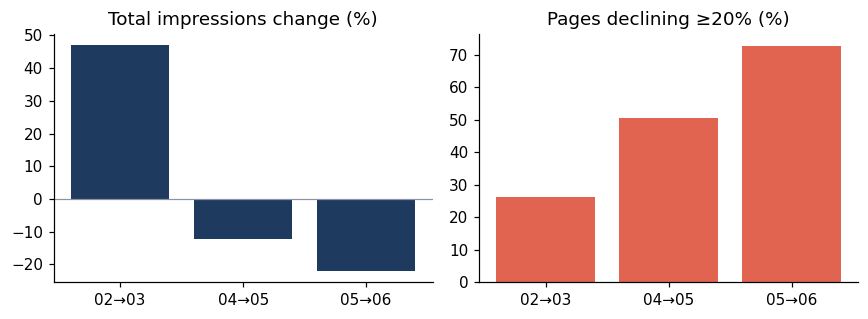

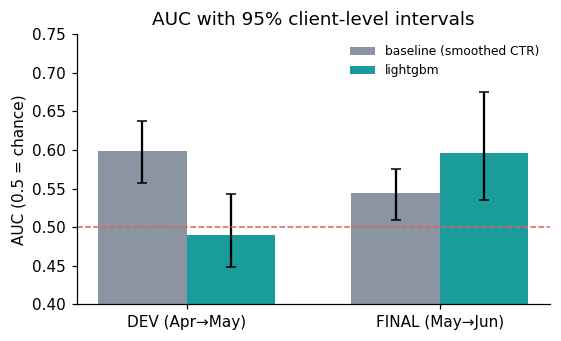

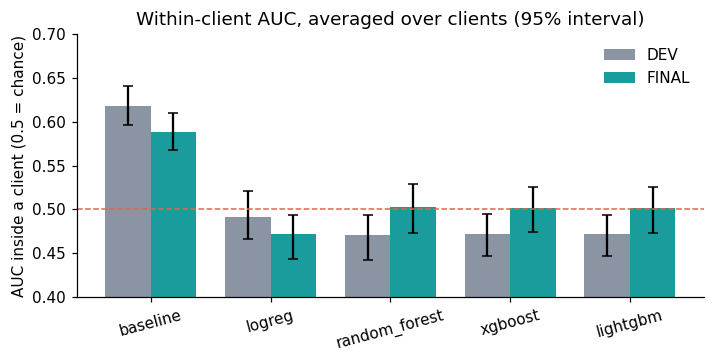

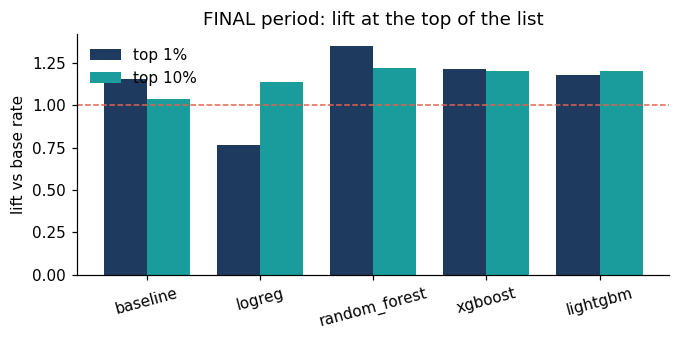

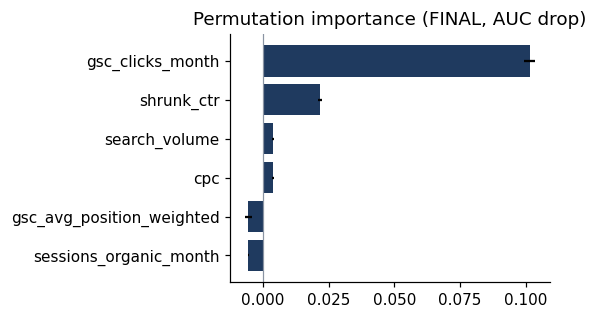

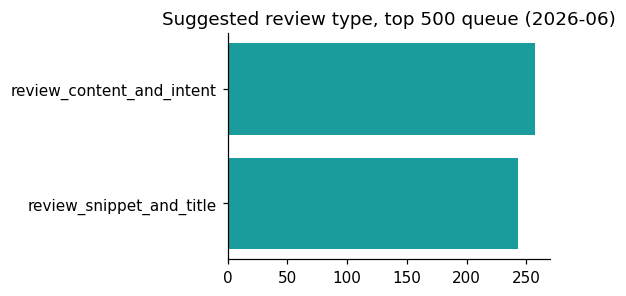

In [13]:
import matplotlib
import matplotlib.pyplot as plt
plt.rcParams.update({"font.size": 10, "axes.spines.top": False, "axes.spines.right": False, "figure.dpi": 110})
NAVY, TEAL, CORAL, GREY = "#1f3a5f", "#1a9c9c", "#e0644f", "#8a94a3"

def save(fig, name):
    fig.tight_layout(); fig.savefig(f"{OUTDIR}/{name}.svg"); fig.savefig(f"{OUTDIR}/{name}.png", dpi=150); plt.show()

# 1. the regime differs by period
fig, ax = plt.subplots(1, 2, figsize=(8, 3))
labels = [f"{r['decision_month'][5:]}→{r['outcome_month'][5:]}" for r in regime]
ax[0].bar(labels, [r["agg_impressions_change"] * 100 for r in regime], color=NAVY); ax[0].axhline(0, color=GREY, lw=0.8)
ax[0].set_title("Total impressions change (%)")
ax[1].bar(labels, [r["decline_rate"] * 100 for r in regime], color=CORAL)
ax[1].set_title("Pages declining ≥20% (%)")
save(fig, "fig1_regime")

# 2. AUC with client-level intervals
fig, ax = plt.subplots(figsize=(5.2, 3.2)); w = 0.35
for j, (nm, key, col) in enumerate([("baseline (smoothed CTR)", "baseline", GREY), (PRIMARY, "primary", TEAL)]):
    vals = [comparison[p][f"auc_{key}"] for p in ["DEV", "FINAL"]]
    errs = [[comparison[p][f"auc_{key}"] - comparison[p][f"auc_{key}_ci"][0] for p in ["DEV", "FINAL"]],
            [comparison[p][f"auc_{key}_ci"][1] - comparison[p][f"auc_{key}"] for p in ["DEV", "FINAL"]]]
    ax.bar(np.arange(2) + (j - 0.5) * w, vals, w, yerr=errs, color=col, label=nm, capsize=3)
ax.axhline(0.5, color=CORAL, lw=1, ls="--"); ax.set_xticks(range(2)); ax.set_xticklabels(["DEV (Apr→May)", "FINAL (May→Jun)"])
ax.set_ylim(0.4, 0.75); ax.set_ylabel("AUC (0.5 = chance)"); ax.legend(frameon=False, fontsize=8)
ax.set_title("AUC with 95% client-level intervals")
save(fig, "fig2_auc")

# 2b. within-client AUC for every model (the view that decides the engine)
fig, ax = plt.subplots(figsize=(6.6, 3.4)); w = 0.38
cols = {"DEV": GREY, "FINAL": TEAL}
for j, p_ in enumerate(["DEV", "FINAL"]):
    vals = [within_all[p_][m]["macro_auc"] for m in MODEL_ORDER]
    lo = [within_all[p_][m]["macro_auc"] - within_all[p_][m]["macro_auc_ci"][0] for m in MODEL_ORDER]
    hi = [within_all[p_][m]["macro_auc_ci"][1] - within_all[p_][m]["macro_auc"] for m in MODEL_ORDER]
    ax.bar(np.arange(len(MODEL_ORDER)) + (j - 0.5) * w, vals, w, yerr=[lo, hi], color=cols[p_], label=p_, capsize=3)
ax.axhline(0.5, color=CORAL, lw=1, ls="--"); ax.set_xticks(range(len(MODEL_ORDER))); ax.set_xticklabels(MODEL_ORDER, rotation=15)
ax.set_ylim(0.4, 0.7); ax.set_ylabel("AUC inside a client (0.5 = chance)"); ax.legend(frameon=False)
ax.set_title("Within-client AUC, averaged over clients (95% interval)")
save(fig, "fig2b_within_client")

# 3. lift on FINAL
fig, ax = plt.subplots(figsize=(6.2, 3.2)); sub = results_df[results_df["period"] == "FINAL"].set_index("model").loc[MODEL_ORDER]
xs = np.arange(len(MODEL_ORDER)); w = 0.38
ax.bar(xs - w / 2, sub["lift_top1pct"], w, color=NAVY, label="top 1%"); ax.bar(xs + w / 2, sub["lift_top10pct"], w, color=TEAL, label="top 10%")
ax.axhline(1, color=CORAL, lw=1, ls="--"); ax.set_xticks(xs); ax.set_xticklabels(MODEL_ORDER, rotation=15)
ax.set_ylabel("lift vs base rate"); ax.legend(frameon=False); ax.set_title("FINAL period: lift at the top of the list")
save(fig, "fig3_lift")

# 4. importance
fig, ax = plt.subplots(figsize=(5.2, 3)); d = importance_df.iloc[::-1]
ax.barh(d["feature"], d["auc_drop_mean"], xerr=d["auc_drop_std"], color=NAVY); ax.axvline(0, color=GREY, lw=0.8)
ax.set_title("Permutation importance (FINAL, AUC drop)")
save(fig, "fig4_importance")

# 5. action mix
fig, ax = plt.subplots(figsize=(5.2, 2.8)); am = pd.Series(queue_stats["action_mix_top500"]).sort_values()
ax.barh(am.index, am.values, color=TEAL); ax.set_title(f"Suggested review type, top 500 queue ({SCORE_MONTH})")
save(fig, "fig5_actions")

In [14]:
import platform, sklearn
results = {
    "config": {"decline_cut": DECLINE_CUT, "k_shrink": K_SHRINK, "seed": SEED, "n_boot": N_BOOT, "primary_model": PRIMARY,
               "periods": {k: {"features_from": v[0], "label_from": v[1]} for k, v in PERIODS.items()}, "score_month": SCORE_MONTH,
               "features": FEATURES, "reference_ctr_train": float(prep.pop_ctr)},
    "leakage_control": {"honest_cv_auc": float(honest), "with_label_ingredients_cv_auc": float(leaky)},
    "regime": regime_df.round(4).to_dict("records"),
    "results": results_df.round(4).to_dict("records"),
    "comparison": comparison,
    "within_client_all": within_all,
    "within_client_by_position": by_pos,
    "sensitivity": {p: pd.DataFrame(v).round(4).to_dict("records") for p, v in sens.items()},
    "top50_concentration": conc,
    "importance": importance_df.round(5).to_dict("records"),
    "queue": {"stats": queue_stats, "top50": queue_public},
    "environment": {"python": platform.python_version(), "pandas": pd.__version__, "numpy": np.__version__,
                    "sklearn": sklearn.__version__, "lightgbm": lgb.__version__, "duckdb": duckdb.__version__},
}
with open(f"{OUTDIR}/results.json", "w") as fh:
    json.dump(results, fh, default=float)
print("Saved:", sorted(os.listdir(OUTDIR)))
short = dict(results); short["queue"] = {"stats": queue_stats, "top50": queue_public[:15]}   # full queue stays in results.json
print("\n===== COPY EVERYTHING BETWEEN THE LINES =====")
print(json.dumps(short, default=float, separators=(",", ":")))
print("===== END =====")

Saved: ['fig1_regime.png', 'fig1_regime.svg', 'fig2_auc.png', 'fig2_auc.svg', 'fig2b_within_client.png', 'fig2b_within_client.svg', 'fig3_lift.png', 'fig3_lift.svg', 'fig4_importance.png', 'fig4_importance.svg', 'fig5_actions.png', 'fig5_actions.svg', 'results.json']

===== COPY EVERYTHING BETWEEN THE LINES =====
{"config":{"decline_cut":-0.2,"k_shrink":50,"seed":42,"n_boot":200,"primary_model":"lightgbm","periods":{"TRAIN":{"features_from":"2026-02","label_from":"2026-03"},"DEV":{"features_from":"2026-04","label_from":"2026-05"},"FINAL":{"features_from":"2026-05","label_from":"2026-06"}},"score_month":"2026-06","features":["gsc_avg_position_weighted","gsc_clicks_month","sessions_organic_month","search_volume","cpc","shrunk_ctr"],"reference_ctr_train":0.0032703111205374005},"leakage_control":{"honest_cv_auc":0.6154042763246078,"with_label_ingredients_cv_auc":0.9604498922491237},"regime":[{"period":"TRAIN","decision_month":"2026-02","outcome_month":"2026-03","pages":145066,"clients":41,

## Self-check

Before you submit, confirm each line honestly:

- ✅ Every section above is filled — markdown thinking AND the code that backs it
- ✅ The notebook runs top to bottom with no errors (Runtime → Run all)
- ✅ No client names, URLs, or private queries anywhere
- ✅ My claims use careful words: observed, measured, directional, decision-support
- ✅ Committed to my repo under `work/notebooks/` — then submit your repo URL on the card. Done.